In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = os.path.expanduser("~/gcs-data/Full_data")
os.listdir(DATA_DIR)

['2020_cleaned.csv',
 'country_continent_map.csv',
 'epicov_2020_200k.csv',
 'epicov_2021_200k.csv',
 'epicov_2023_200k.parquet',
 'epicov_2025_200k.parquet',
 'models']

In [3]:
df20 = pd.read_csv(os.path.join(DATA_DIR, "epicov_2020_200k.csv"))
df21 = pd.read_csv(os.path.join(DATA_DIR, "epicov_2021_200k.csv"))
df23 = pd.read_parquet(os.path.join(DATA_DIR, "epicov_2023_200k.parquet"))
df25 = pd.read_parquet(os.path.join(DATA_DIR, "epicov_2025_200k.parquet"))
df20.shape, df21.shape, df23.shape, df25.shape

/tmp/ipykernel_12097/1650611895.py:1: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df20 = pd.read_csv(os.path.join(DATA_DIR, "epicov_2020_200k.csv"))


((200524, 18), (213997, 18), (203488, 18), (177116, 18))

In [4]:
set(df20.columns) == set(df21.columns) == set(df23.columns) == set(df25.columns)

True

In [5]:
cols = ["Accession ID", "Collection date", "Submission date"]
df = pd.concat([df20[cols], df21[cols], df23[cols], df25[cols]], axis=0)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 795125 entries, 0 to 177115
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   Accession ID     795125 non-null  object
 1   Collection date  795125 non-null  object
 2   Submission date  795125 non-null  object
dtypes: object(3)
memory usage: 24.3+ MB


In [10]:
df.rename(columns={"Accession ID": "accession_id", "Collection date": "collection_date", "Submission date": "submission_date"}, inplace=True)
# 'mixed' allows pandas to infer formats row-by-row
df["collection_date"] = pd.to_datetime(df["collection_date"], format='mixed')
df["submission_date"] = pd.to_datetime(df["submission_date"], format='mixed')
df["collection_yr"] = df["collection_date"].dt.year
df["submission_yr"] = df["submission_date"].dt.year
# Extract Day of Year (1-365) to align Jan 2020 with Jan 2022
df['collection_doy'] = df['collection_date'].dt.dayofyear
df['submission_doy'] = df['submission_date'].dt.dayofyear
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 795125 entries, 0 to 177115
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   accession_id     795125 non-null  object        
 1   collection_date  795125 non-null  datetime64[ns]
 2   submission_date  795125 non-null  datetime64[ns]
 3   collection_doy   795125 non-null  int32         
 4   submission_doy   795125 non-null  int32         
 5   collection_yr    795125 non-null  int32         
 6   submission_yr    795125 non-null  int32         
dtypes: datetime64[ns](2), int32(4), object(1)
memory usage: 36.4+ MB


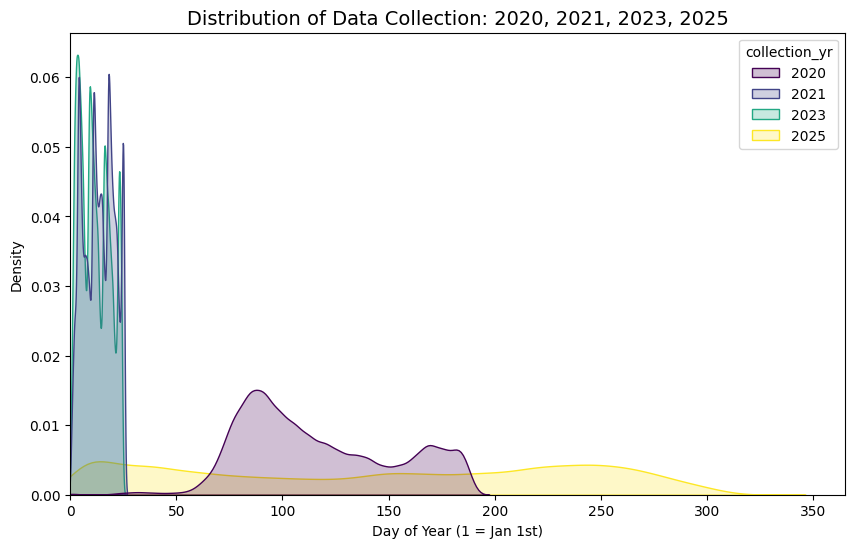

In [14]:
# 3. Plotting
plt.figure(figsize=(10, 6))

# Option A: Density Plot (The "Spike" vs "Hill")
# 'common_norm=False' allows each year to be normalized to its own volume, 
# showing the shape clearly regardless of total count differences.
sns.kdeplot(data=df, x='collection_doy', hue='collection_yr', fill=True, common_norm=False, palette='viridis')

plt.title("Distribution of Data Collection: 2020, 2021, 2023, 2025", fontsize=14)
plt.xlabel("Day of Year (1 = Jan 1st)")
plt.xlim(0, 365) # Lock to a full year view
plt.show()

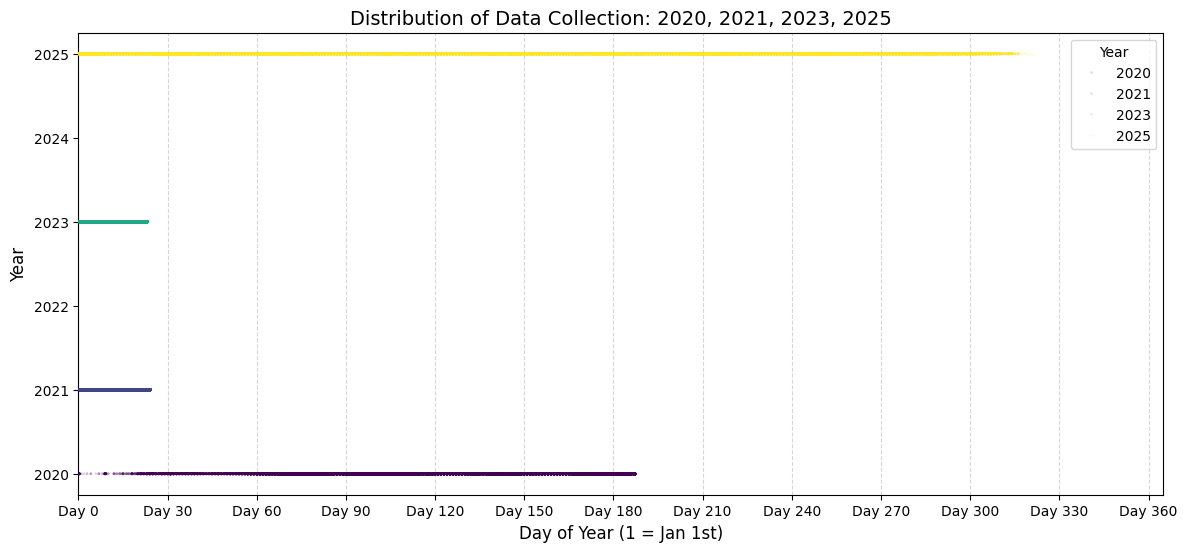

In [15]:
plt.figure(figsize=(14, 6))

# 3. Create Strip Plot
    # TIP: We use .sample(frac=0.1) to plot only 10% of data for speed/clarity. 
    # If you want all data, remove .sample() but lower 'alpha' and 'size'.
sns.stripplot(
    # data=df.sample(frac=0.1, random_state=42),
    data=df,  
    x='collection_doy', 
    y='collection_yr',           # Categorical Y-axis separates the years
    hue='collection_yr',         # Colors them differently
    jitter=0.25,        # Adds random vertical noise so dots don't overlap perfectly
    size=2,             # Keep dots small
    alpha=0.15,          # High transparency to show density (darker = more data)
    palette='viridis'
)

# plt.title("Timeline of Data Collection by Year (Strip Plot)", fontsize=14)
plt.title("Distribution of Data Collection: 2020, 2021, 2023, 2025", fontsize=14)
plt.xlabel("Day of Year (1 = Jan 1st)", fontsize=12)
plt.ylabel("Year", fontsize=12)
plt.xlim(0, 365)  # Lock axis to full year
plt.grid(True, axis='x', linestyle='--', alpha=0.5)

plt.xticks(ticks=np.arange(0, 366, 30), labels=[f"Day {i}" for i in np.arange(0, 366, 30)])
plt.legend(title='Year', loc='upper right')

plt.show()